## From this notebook, we are going to build classification models.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('sales.csv')
df.dropna(subset=['price'], inplace=True)

In [4]:
df['year'] = pd.to_datetime(df.purchase_date).dt.year
train_raw = df[df.year < 2015]
test_raw = df[df.year >= 2015]

df

,cost,price,weight,purchase_date,product_type,product_level,maker,ingredient,height,width,depth,year
0,$333k,"$300,492",3 Ton 90 Kg,Dec 19 2008,"Q,B",advanced,M14122,"IN732052,IN732053",2.76 meters,97 cm,26 cm,2008
1,NaN,"$430,570",3 Ton 30 Kg,Sep 10 1997,"J,D",basic,NaN,"IN732054,IN732055,IN732056,IN732057,IN732058",2.67 meters,98 cm,26 cm,1997
2,$270k,"$213,070",3 Ton 40 Kg,Sep 05 2001,"J,D",basic,NaN,"IN732054,IN732059,IN732060",3.0 meters,93 cm,24 cm,2001
3,NaN,"$229,174",3 Ton 50 Kg,Dec 23 2016,U,advanced,M14123,"IN732061,IN732062,IN732063",2.5 meters,102 cm,27 cm,2016
4,$97k,"$122,659",2 Ton 970 Kg,Jan 12 2000,"D,R",advanced,NaN,"IN732064,IN732065,IN732066",2.47 meters,101 cm,26 cm,2000
...,...,...,...,...,...,...,...,...,...,...,...,...
3192,NaN,"$93,349",3 Ton 0 Kg,Nov 25 2016,D,advanced,M14904,"IN732490,IN732338,IN732503,IN732435,IN732583",2.02 meters,112 cm,29 cm,2016
3193,NaN,"$40,384",2 Ton 830 Kg,May 25 2007,"J,B",intermediate,M14578,"IN732832,IN732166,IN733162,IN733785,IN732069,I...",2.15 meters,106 cm,28 cm,2007
3194,NaN,"$1,074,844",3 Ton 80 Kg,Dec 16 2016,C,intermediate,"M14883,M15011","IN733462,IN732654,IN732149,IN733067,IN734088,I...",2.84 meters,96 cm,25 cm,2016
3195,$44k,"$55,931",2 Ton 950 Kg,Apr 12 2002,R,advanced,M14341,IN732587,2.52 meters,100 cm,26 cm,2002


# 1. Generate Targets

<font color='red'>Assignment:</font> We define a categorical target **luxury**. If **price** is higher than 500k dollars, we say this item is a **luxury**, and use integer 1 to mark it as positive. Otherwise, we use 0 to mark it as negative. Get the target Series for training and testing data sets (**y_train** and **y_test**), respectively.

In [5]:
#def classify_price(x):
    x = x.strip("$").replace(",", "")
    if float(x) > 500000:
        return 1  # Luxury item
    else:
        return 0  # Non-luxury item

# Apply the classification function to create the target column
#df['price'] = df['price'].apply(classify_price)
df

IndentationError: unexpected indent (392786270.py, line 2)

In [6]:
def classify_price(price):
    price = price.strip("$").replace(",", "")
    if float(price) > 500000:
        return 1  # Luxury item
    else:
        return 0  # Non-luxury item

# Apply the classification function to create the target column
df['price'] = df['price'].apply(lambda x: classify_price(x))
df

,cost,price,weight,purchase_date,product_type,product_level,maker,ingredient,height,width,depth,year
0,$333k,0,3 Ton 90 Kg,Dec 19 2008,"Q,B",advanced,M14122,"IN732052,IN732053",2.76 meters,97 cm,26 cm,2008
1,NaN,0,3 Ton 30 Kg,Sep 10 1997,"J,D",basic,NaN,"IN732054,IN732055,IN732056,IN732057,IN732058",2.67 meters,98 cm,26 cm,1997
2,$270k,0,3 Ton 40 Kg,Sep 05 2001,"J,D",basic,NaN,"IN732054,IN732059,IN732060",3.0 meters,93 cm,24 cm,2001
3,NaN,0,3 Ton 50 Kg,Dec 23 2016,U,advanced,M14123,"IN732061,IN732062,IN732063",2.5 meters,102 cm,27 cm,2016
4,$97k,0,2 Ton 970 Kg,Jan 12 2000,"D,R",advanced,NaN,"IN732064,IN732065,IN732066",2.47 meters,101 cm,26 cm,2000
...,...,...,...,...,...,...,...,...,...,...,...,...
3192,NaN,0,3 Ton 0 Kg,Nov 25 2016,D,advanced,M14904,"IN732490,IN732338,IN732503,IN732435,IN732583",2.02 meters,112 cm,29 cm,2016
3193,NaN,0,2 Ton 830 Kg,May 25 2007,"J,B",intermediate,M14578,"IN732832,IN732166,IN733162,IN733785,IN732069,I...",2.15 meters,106 cm,28 cm,2007
3194,NaN,1,3 Ton 80 Kg,Dec 16 2016,C,intermediate,"M14883,M15011","IN733462,IN732654,IN732149,IN733067,IN734088,I...",2.84 meters,96 cm,25 cm,2016
3195,$44k,0,2 Ton 950 Kg,Apr 12 2002,R,advanced,M14341,IN732587,2.52 meters,100 cm,26 cm,2002


<font color='red'>Assignment:</font> Visualize the comparison between the numbers of positive and negative data points. **Hint:** You could use either bar chart or pie chart.

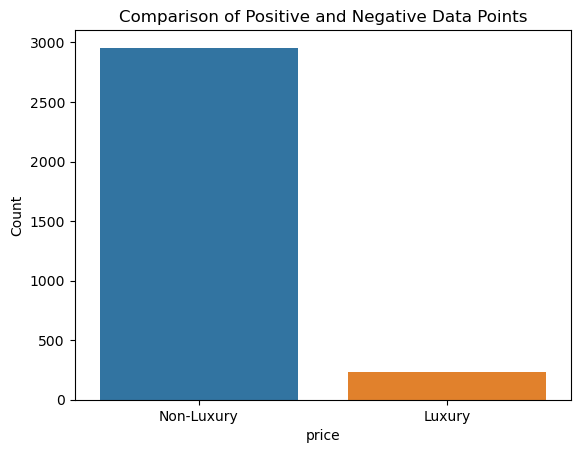

In [7]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Create a bar plot or count plot
sns.countplot(x='price', data=df)
plt.xlabel('price')
plt.ylabel('Count')
plt.title('Comparison of Positive and Negative Data Points')
plt.xticks([0, 1], ['Non-Luxury', 'Luxury'])  # Optional: customize x-axis tick labels
plt.show()





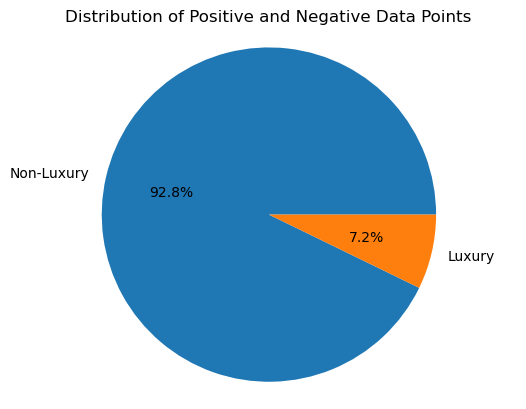

In [9]:
counts = df['price'].value_counts()
plt.pie(counts, labels=['Non-Luxury', 'Luxury'], autopct='%1.1f%%')
plt.title('Distribution of Positive and Negative Data Points')
plt.axis('equal')
plt.show()

<font color='red'>Question:</font> What is the definition of base rate?

In [ ]:
minimum interest rate set by a central bank or monetary authority that serves as a benchmark for determining the 
interest rates of various financial products and services within an economy. 

<font color='red'>Question:</font> What is the base rate in this case?

In [ ]:
accuracy

# 2. Simplest Models

## 2.1 All Negative Model

### 2.1.1 Model Building

<font color='red'>Assignment:</font> Build a model which always predicts 0.

In [10]:
from sklearn.dummy import DummyClassifier

# Create the All Negative Model
model = DummyClassifier(strategy="constant", constant=0)

# Train the model (not required for the All Negative Model)



<font color='red'>Assignment:</font> Make predictions for both training and testing data.

In [11]:
train_raw = df[df.year < 2015]
test_raw = df[df.year >= 2015]
train_raw

,cost,price,weight,purchase_date,product_type,product_level,maker,ingredient,height,width,depth,year
0,$333k,0,3 Ton 90 Kg,Dec 19 2008,"Q,B",advanced,M14122,"IN732052,IN732053",2.76 meters,97 cm,26 cm,2008
1,NaN,0,3 Ton 30 Kg,Sep 10 1997,"J,D",basic,NaN,"IN732054,IN732055,IN732056,IN732057,IN732058",2.67 meters,98 cm,26 cm,1997
2,$270k,0,3 Ton 40 Kg,Sep 05 2001,"J,D",basic,NaN,"IN732054,IN732059,IN732060",3.0 meters,93 cm,24 cm,2001
4,$97k,0,2 Ton 970 Kg,Jan 12 2000,"D,R",advanced,NaN,"IN732064,IN732065,IN732066",2.47 meters,101 cm,26 cm,2000
5,$59k,0,2 Ton 930 Kg,Aug 19 2011,H,super advanced,M14124,"IN732067,IN732068,IN732069,IN732070,IN732071,I...",2.71 meters,96 cm,25 cm,2011
...,...,...,...,...,...,...,...,...,...,...,...,...
3190,$254k,0,3 Ton 40 Kg,Apr 20 2012,D,intermediate,M14261,"IN732220,IN732456,IN733681,IN732831,IN733123,I...",2.02 meters,113 cm,30 cm,2012
3191,$91k,0,2 Ton 890 Kg,Jul 12 2002,D,advanced,M14904,"IN732503,IN732583,IN732373,IN732338,IN732347,I...",2.52 meters,99 cm,26 cm,2002
3193,NaN,0,2 Ton 830 Kg,May 25 2007,"J,B",intermediate,M14578,"IN732832,IN732166,IN733162,IN733785,IN732069,I...",2.15 meters,106 cm,28 cm,2007
3195,$44k,0,2 Ton 950 Kg,Apr 12 2002,R,advanced,M14341,IN732587,2.52 meters,100 cm,26 cm,2002


In [12]:
features=list(train_raw.columns)
target='price'
features.remove(target)
X_train = train_raw[features]
X_test = test_raw[features]
y_train = train_raw[target]
y_test = test_raw[target]


In [13]:
model.fit(X_train, y_train )
y_train_pre=model.predict(X_train)


In [14]:
y_test_pre=model.predict(X_test)

### 2.1.2 Accuracy

<font color='red'>Assignment:</font> Calculate the training and testing **accuracy_score**s.

In [15]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_test_pre)

# Print the accuracy score
print("Accuracy:", accuracy)

Accuracy: 0.8927738927738927


<font color='red'>Question:</font> How is accuracy score calculated?

In [ ]:
accuracy = (number of correct predictions) / (total number of predictions)

<font color='red'>Question:</font> Are the accuracy scores good? Why is that? Is the model useful?

In [ ]:
The accuracy score is good in this case. Because most of them are negative but this model is not useful.

<font color='red'>Question:</font> How is accuracy score related to base rate?

In [ ]:
By comparing the accuracy score of a model with the base rate, you can determine whether the model's predictions are
better than random chance or a simple rule.

### 2.1.2 Precision

<font color='red'>Assignment:</font> Calculate the training and testing **precision_score**s.

In [16]:
from sklearn.metrics import precision_score

# Assuming you have the true labels y_true and predicted labels y_pred
train_precision = precision_score(y_train, y_train_pre,average='macro')  # Set zero_division to 1
test_precision = precision_score(y_test, y_test_pre,average='macro')  # Set zero_division to 1


# Print the precision scores

print("Training Precision Score:", train_precision)
print("Testing Precision Score:", test_precision)

Training Precision Score: 0.4666303953572724
Testing Precision Score: 0.44638694638694637


/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<font color='red'>Question:</font> How is **precision_score** calculated?

the difference between the accuracy and precision:
Accuracy=TF+TP/T
precision=TP/TP+FP

<font color='red'>Question:</font> If the **precision_score** for a model is 80%, what does it mean?

### 2.1.3 Recall

<font color='red'>Assignment:</font> Calculate the training and testing **recall_score**s.

In [111]:
from sklearn.metrics import recall_score

# Calculate training recall score
recall_train = recall_score(y_train, y_train_pre)

# Calculate testing recall score
recall_test = recall_score(y_test, y_test_pre)
print ('recall for train:', recall_train)
print ('recall for train:', recall_test)


recall for train: 0.0
recall for train: 0.0


<font color='red'>Question:</font> How is **recall_score** calculated?

In [ ]:
Recall = TP / (TP + FN)

<font color='red'>Question:</font> If the **recall_score** for a model is 80%, what does it mean?

In [ ]:
the model correctly identifies 80% of the positive instances in the dataset.

### 2.1.4 F1 Score

<font color='red'>Assignment:</font> Calculate the training and testing **f1_score**s.

In [113]:
from sklearn.metrics import f1_score

# Calculate training F1 score
f1_train = f1_score(y_train, y_train_pre)

# Calculate testing F1 score
f1_test = f1_score(y_test, y_test_pre)

print('f1 score for train:',f1_train)
print('f1 score for train:',f1_test)

f1 score for train: 0.0
f1 score for train: 0.0


<font color='red'>Question:</font> How is **f1_score** calculated?

In [ ]:
F1 = 2 * (precision * recall) / (precision + recall)   
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)

<font color='red'>Question:</font> Why do we need **f1_score**?

In [ ]:
Balancing Precision and Recall.Handling Class Imbalance.
Model Selection:The F1 score is commonly used for model selection or hyperparameter tuning. It helps in comparing 
different models or different settings of the same model by considering both precision and recall. Depending on 
the problem and the desired trade-off between precision and recall, a higher F1 score may be preferred over a model 
with higher precision or recall alone.
Practical Applications:The F1 score is often used in real-world applications where there are costs associated with 
false positives and false negatives. For example, in medical diagnosis, both false positives and false negatives have
consequences. The F1 score helps in evaluating the model's performance in such scenarios, ensuring a balance between 
correctly identifying positive instances and minimizing incorrect predictions.

### 2.1.5 Classification Report

<font color='red'>Assignment:</font> Use **classification_report** to get systematic idea about model performance.

In [114]:
from sklearn.metrics import classification_report

# Calculate the classification report for the training set
report_train = classification_report(y_train, y_train_pre)

# Calculate the classification report for the testing set
report_test = classification_report(y_test, y_test_pre)

# Print the classification report for the training set
print("Training Classification Report:")
print(report_train)

# Print the classification report for the testing set
print("Testing Classification Report:")
print(report_test)







Training Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97      2573
           1       0.00      0.00      0.00       184

    accuracy                           0.93      2757
   macro avg       0.47      0.50      0.48      2757
weighted avg       0.87      0.93      0.90      2757

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       383
           1       0.00      0.00      0.00        46

    accuracy                           0.89       429
   macro avg       0.45      0.50      0.47       429
weighted avg       0.80      0.89      0.84       429



/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Use

### 2.1.6 Confusion Matrix

<font color='red'>Assignment:</font> Get the **confusion_matrix** of the model.

In [115]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the training set
cm_train = confusion_matrix(y_train, y_train_pre)

# Calculate the confusion matrix for the testing set
cm_test = confusion_matrix(y_test, y_test_pre)

# Print the confusion matrix for the training set
print("Training Confusion Matrix:")
print(cm_train)

# Print the confusion matrix for the testing set
print("Testing Confusion Matrix:")
print(cm_test)

Training Confusion Matrix:
[[2573    0]
 [ 184    0]]
Testing Confusion Matrix:
[[383   0]
 [ 46   0]]


<font color='red'>Question:</font> What does every element in the confusion matrix represent, respectively?

In [ ]:
 predicted  TP FP
 predicted  FN TN

<font color='red'>Question:</font> How can you calculate recall and precision with a confusion matrix?

In [ ]:
Recall = TP / (TP + FN)   Precision = TP / (TP + FP)

## 2.2 All Positive Model

### 2.2.1 Model Building

<font color='red'>Assignment:</font> Build a model which always predicts 1.

In [118]:
from sklearn.dummy import DummyClassifier

# Create the All Negative Model
model = DummyClassifier(strategy="constant", constant=1)

# Train the model (not required for the All Negative Model)
model.fit(X_train, y_train)
y_train_pre1=model.predict(X_train)
y_test_pre1=model.predict(X_test)

### 2.2.2 Scores and confusion matrices

<font color='red'>Assignment:</font> Calculate the scores and confusion matrices of this model.

In [119]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_test_pre1)

# Print the accuracy score
print("Accuracy:", accuracy)

Accuracy: 0.10722610722610723


In [120]:
from sklearn.metrics import precision_score

# Assuming you have the true labels y_true and predicted labels y_pred
train_precision = precision_score(y_train, y_train_pre1)  # Set zero_division to 1
test_precision = precision_score(y_test, y_test_pre1)  # Set zero_division to 1


# Print the precision scores

print("Training Precision Score:", train_precision)
print("Testing Precision Score:", test_precision)

Training Precision Score: 0.06673920928545521
Testing Precision Score: 0.10722610722610723


In [121]:
from sklearn.metrics import recall_score

# Calculate training recall score
recall_train = recall_score(y_train, y_train_pre1)

# Calculate testing recall score
recall_test = recall_score(y_test, y_test_pre1)
print ('recall for train:', recall_train)
print ('recall for train:', recall_test)


recall for train: 1.0
recall for train: 1.0


In [122]:
from sklearn.metrics import f1_score

# Calculate training F1 score
f1_train = f1_score(y_train, y_train_pre1)

# Calculate testing F1 score
f1_test = f1_score(y_test, y_test_pre1)

print('f1 score for train:',f1_train)
print('f1 score for train:',f1_test)

f1 score for train: 0.12512750765045902
f1 score for train: 0.19368421052631582


In [124]:
from sklearn.metrics import classification_report

# Calculate the classification report for the training set
report_train = classification_report(y_train, y_train_pre1)

# Calculate the classification report for the testing set
report_test = classification_report(y_test, y_test_pre1)

# Print the classification report for the training set
print("Training Classification Report:")
print(report_train)

# Print the classification report for the testing set
print("Testing Classification Report:")
print(report_test)


Training Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2573
           1       0.07      1.00      0.13       184

    accuracy                           0.07      2757
   macro avg       0.03      0.50      0.06      2757
weighted avg       0.00      0.07      0.01      2757

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       383
           1       0.11      1.00      0.19        46

    accuracy                           0.11       429
   macro avg       0.05      0.50      0.10       429
weighted avg       0.01      0.11      0.02       429



/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Use

In [125]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the training set
cm_train = confusion_matrix(y_train, y_train_pre1)

# Calculate the confusion matrix for the testing set
cm_test = confusion_matrix(y_test, y_test_pre1)

# Print the confusion matrix for the training set
print("Training Confusion Matrix:")
print(cm_train)

# Print the confusion matrix for the testing set
print("Testing Confusion Matrix:")
print(cm_test)

Training Confusion Matrix:
[[   0 2573]
 [   0  184]]
Testing Confusion Matrix:
[[  0 383]
 [  0  46]]


<font color='red'>Question:</font> What are the difference between all-positive and all-negative models?

In [ ]:
he all-positive model assumes that everything is positive, while the all-negative model assumes that everything is 
negative. These models serve as simple baselines for comparison and evaluation of more sophisticated classification 
models. Understanding their performance characteristics can provide insights into the strengths and weaknesses of 
more complex models.